In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [43]:
conn = psycopg2.connect(
    host="localhost",
    database="PT",
    user="postgres",
    password="12345", 
    port=5432
)


query = "SELECT * FROM customer_view;"
df = pd.read_sql(query, conn)

conn.close()

C:\Users\amet1\AppData\Local\Temp\ipykernel_26648\2874425006.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [44]:
df.head()

,m_code,due_invoice_date,contract_date,consumption,last_financial_installment,remaining_financial_installments,bank_installment,remaining_bank_installments,customer_type,total_financial_amount,invoice_payment_date,payment_status
0,308,202501,2016-10-22,0,0,0.0,0.0,0.0,2,17,2025-02-15,1
1,308,202501,2017-04-13,12,0,0.0,0.0,0.0,0,54,2025-01-28,1
2,308,202501,2016-10-23,21,0,0.0,0.0,0.0,0,81,2025-01-07,1
3,308,202501,2016-10-17,12,0,0.0,0.0,0.0,0,54,2025-01-07,1
4,308,202501,2016-10-17,0,0,0.0,0.0,0.0,2,18,2025-01-27,1


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475249 entries, 0 to 3475248
Data columns (total 12 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   m_code                            int64  
 1   due_invoice_date                  int64  
 2   contract_date                     object 
 3   consumption                       int64  
 4   last_financial_installment        int64  
 5   remaining_financial_installments  float64
 6   bank_installment                  float64
 7   remaining_bank_installments       float64
 8   customer_type                     int64  
 9   total_financial_amount            int64  
 10  invoice_payment_date              object 
 11  payment_status                    object 
dtypes: float64(3), int64(6), object(3)
memory usage: 318.2+ MB


In [46]:
df['contract_date'] = pd.to_datetime(df['contract_date'], errors='coerce')
df['invoice_payment_date'] = pd.to_datetime(df['invoice_payment_date'], errors='coerce')

In [47]:
df.isnull().sum()

m_code                                   0
due_invoice_date                         0
contract_date                         1103
consumption                              0
last_financial_installment               0
remaining_financial_installments         0
bank_installment                         0
remaining_bank_installments              0
customer_type                            0
total_financial_amount                   0
invoice_payment_date                341983
payment_status                           0
dtype: int64

In [48]:
df = df.dropna(subset=['contract_date'])

In [49]:
df.loc[df['invoice_payment_date'].isna(), 'payment_status'] = 0

In [50]:
df['payment_status'] = pd.to_numeric(df['payment_status'], errors='coerce').astype('Int64')

In [32]:
#placeholder
df['invoice_payment_date'] = df['invoice_payment_date'].fillna(pd.Timestamp("1900-01-01"))

In [51]:
df.isnull().sum()

m_code                                   0
due_invoice_date                         0
contract_date                            0
consumption                              0
last_financial_installment               0
remaining_financial_installments         0
bank_installment                         0
remaining_bank_installments              0
customer_type                            0
total_financial_amount                   0
invoice_payment_date                341983
payment_status                           0
dtype: int64

In [52]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicated: {duplicate_count}")

df = df.drop_duplicates()

duplicate_count = df.duplicated().sum()
print(f"after removal: {duplicate_count}")

Number of duplicated: 688979
after removal: 0


In [67]:
numeric_cols = ['consumption', 'customer_type', 'total_financial_amount']

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    count_outliers = len(outliers)
    
    outlier_summary[col] = {
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outliers_Count': count_outliers,
        'Outliers_Percentage': round((count_outliers / len(df)) * 100, 3)
    }
    
outlier_df = pd.DataFrame(outlier_summary).T
outlier_df.sort_values('Outliers_Percentage', ascending=False, inplace=True)

print("\n Outlier Summary by Column:")
print(outlier_df)




 Outlier Summary by Column:
                        Lower_Bound  Upper_Bound  Outliers_Count  \
consumption                   -34.5         57.5             0.0   
customer_type                  -3.0          5.0             0.0   
total_financial_amount       -109.5        230.5             0.0   

                        Outliers_Percentage  
consumption                             0.0  
customer_type                           0.0  
total_financial_amount                  0.0  


In [66]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df.loc[df[col] < lower, col] = lower
    df.loc[df[col] > upper, col] = upper


C:\Users\amet1\AppData\Local\Temp\ipykernel_26648\2285431349.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-34.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col] < lower, col] = lower
C:\Users\amet1\AppData\Local\Temp\ipykernel_26648\2285431349.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-109.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col] < lower, col] = lower


In [53]:
min_date = df['contract_date'].min()
max_date = df['contract_date'].max()

print("Oldest contract date:", min_date.date())
print("Newest contract date:", max_date.date())

Oldest contract date: 2004-09-16
Newest contract date: 2025-08-25


In [54]:
import datetime
df['contract_age_days'] = (datetime.datetime.now() - df['contract_date']).dt.days
df = df.drop(['contract_date', 'invoice_payment_date'], axis=1)

In [68]:
df

,m_code,due_invoice_date,consumption,last_financial_installment,remaining_financial_installments,bank_installment,remaining_bank_installments,customer_type,total_financial_amount,payment_status,contract_age_days
0,308,202501,0.0,0,0.0,0.0,0.0,2,17.0,1,3317
1,308,202501,12.0,0,0.0,0.0,0.0,0,54.0,1,3144
2,308,202501,21.0,0,0.0,0.0,0.0,0,81.0,1,3316
3,308,202501,12.0,0,0.0,0.0,0.0,0,54.0,1,3322
4,308,202501,0.0,0,0.0,0.0,0.0,2,18.0,1,3322
...,...,...,...,...,...,...,...,...,...,...,...
3475241,118,202510,15.0,0,0.0,0.0,0.0,0,78.0,1,3676
3475242,118,202510,0.0,0,0.0,0.0,0.0,2,18.0,1,3873
3475244,118,202510,7.0,0,0.0,0.0,0.0,0,45.0,1,3967
3475245,118,202510,5.0,0,0.0,0.0,0.0,0,37.0,1,3981


In [69]:
df['payment_status'].value_counts()

payment_status
1    2632769
0     152398
Name: count, dtype: Int64

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2785167 entries, 0 to 3475248
Data columns (total 11 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   m_code                            int64  
 1   due_invoice_date                  int64  
 2   consumption                       float64
 3   last_financial_installment        int64  
 4   remaining_financial_installments  float64
 5   bank_installment                  float64
 6   remaining_bank_installments       float64
 7   customer_type                     int64  
 8   total_financial_amount            float64
 9   payment_status                    Int64  
 10  contract_age_days                 int64  
dtypes: Int64(1), float64(5), int64(5)
memory usage: 257.6 MB


In [71]:
X = df.drop('payment_status', axis=1)
y = df['payment_status'].values

In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=101)

In [73]:
from imblearn.over_sampling import SMOTE
print("Before SMOTE - y_train value counts:")
print(pd.Series(y_train).value_counts())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

if isinstance(X_train, pd.DataFrame):
    X_train_res = pd.DataFrame(X_train_res, columns=X_train.columns)

print("\nAfter SMOTE - y_train_res value counts:")
print(pd.Series(y_train_res).value_counts())

print(f"\nShapes -> X_train: {getattr(X_train,'shape',None)}, X_train_res: {X_train_res.shape}")
print(f"          X_test: {getattr(X_test,'shape',None)}, y_train: {getattr(y_train,'shape',None)}, y_test: {getattr(y_test,'shape',None)}")


Before SMOTE - y_train value counts:
1    2105985
0     122148
Name: count, dtype: Int64

After SMOTE - y_train_res value counts:
0.0    2105985
1.0    2105985
Name: count, dtype: int64

Shapes -> X_train: (2228133, 10), X_train_res: (4211970, 10)
          X_test: (557034, 10), y_train: (2228133,), y_test: (557034,)


In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("scaler", StandardScaler()),   
    ("clf", RandomForestClassifier(
        n_estimators=100,
        n_jobs=-1,
        class_weight={0:29, 1:1},
        random_state=42
    ))
])

In [75]:
X_train = X_train_res
y_train = y_train_res

In [76]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(class_weight={0: 29, 1: 1}, n_jobs=-1,
                                        random_state=42))])

In [65]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.681626256206982

Classification Report:
              precision    recall  f1-score   support

         0.0       0.08      0.43      0.13     30250
         1.0       0.96      0.70      0.81    526784

    accuracy                           0.68    557034
   macro avg       0.52      0.56      0.47    557034
weighted avg       0.91      0.68      0.77    557034


Confusion Matrix:
[[ 13009  17241]
 [160104 366680]]


Accuracy: 0.9688066727546335


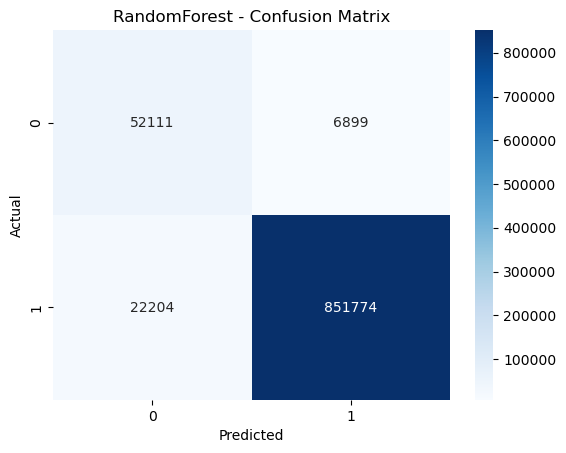

In [35]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix, annot=True, cmap="Blues", fmt="d")
plt.title("RandomForest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
import joblib
joblib.dump(model, "pt_rf_model.pkl")

['pt_rf_model.pkl']

In [37]:
import joblib
joblib.dump(model, "pt_rf_model_compressed.pkl",compress=3)

['pt_rf_model_compressed.pkl']